## Análise do Foco Global das Imagens com Laplace.
| Este código analisa a distribuição de foco da stack de imagens utilizando a variância do Laplaciano, e seleciona as camadas dentro do limiar definido, μ - kσ (k = 0.5), que abrange aproximadamente 67% das imagens.

In [33]:
# Bibliotecas
import os
import re
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
def load_images_from_folder(folder):
    """
    Ordena um conjunto de imagens a partir de uma dataset contendo ordenação 
    númerica crescente a patir da localização da pasta de origem.
    
    """
    
    images = []
    
    try:
        all_files = os.listdir(folder)
    except FileNotFoundError:
        print(f"Erro: A pasta '{folder}' não foi encontrada.")
        return []

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    image_files = [f for f in all_files if f.lower().endswith(valid_extensions)]

    def extract_number(filename):
        match = re.search(r'(\d+)', filename)
        if match:
            return int(match.group(1))
        return 0 

    sorted_files = sorted(image_files, key=extract_number)
    
    print(f"\nOrdem de carregamento detectada: {sorted_files[:5]} ...")

    for filename in sorted_files:
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        
        if img is not None:
            images.append(img)
        else:
            print(f"Aviso: Não foi possível ler {filename}")

    return images


In [35]:
#### Cost Functions
def mse(img1, img2):
    """
    Mean Squared Error.
    Retorna o erro médio do quadrado da unidade de intensidade dos pixels.
    
    """
    diff = img1.astype("float") - img2.astype("float")
    mse = np.mean(diff ** 2)
    return mse

def rmse(img1, img2):
    """
    Root Mean Squared Error.
    Retorna o erro médio na mesma unidade de intensidade dos pixels.

    """
    diff = img1.astype("float") - img2.astype("float")
    mse = np.mean(diff ** 2)
    rmse = np.sqrt(mse)
    return rmse

def ncc(img1, img2):
    """
    Normalized Cross-Correlation.
    Retorna um valor entre -1 e 1 (cosseno da similaridade).

    """
    # Transforma as imagens em vetores 1D.
    v1 = img1.flatten().astype("float")
    v2 = img2.flatten().astype("float")
    dot_product = np.dot(v1, v2)
    
    # Normas (magnitudes) dos vetores.
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    
    if norm1 == 0 or norm2 == 0:
        return 0.0
        
    return dot_product / (norm1 * norm2)

### Gerenciamento dos Gráficos
def on_press(event):
    global debug
    if event.key == 'enter':
        plt.close()
    elif event.key == '0':
        debug = False
        plt.close()

#### Estimate Functions
def estimate(img_base, img_zoom, interval, metric, debug=False):
    """
    Testa vários fatores de escala para encontrar qual faz a img_zoom voltar a ser idêntica à img_base.

    Args:
        img_base: Imagem base (i).
        img_zoom: Imagem zoom (i+1).
        interval: Intervalo de busca da Função de Custo. 
        metric: Define a Função de Custo ('MSE', 'RMSE' ou 'NCC').
        debug: Exibe um gráfico para avaliar a seleção da escala.
    
    Output:
        s: Melhor escala encontrada.
        err: Menor erro encontrado.

    """
    h, w = img_base.shape
    center = (w // 2, h // 2)
    
    errors = []
    scales = []
        
    init = time.time()
    
    # Loop de Otimização.
    margin = int(min(h, w) * 0.1)
    for s_test in interval:
        
        M = cv2.getRotationMatrix2D(center=center, angle=0, scale=s_test)
        img_base_transformed = cv2.warpAffine(img_base, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        
        # Mascaramento.
        roi_base = img_base_transformed[margin:-margin, margin:-margin]
        roi_zoom = img_zoom[margin:-margin, margin:-margin]
        
        if metric == 'MSE':
            err = mse(roi_zoom, roi_base)
        elif metric == 'RMSE':
            err = rmse(roi_zoom, roi_base)
        elif metric == 'NCC':
            err = ncc(roi_zoom, roi_base)
        
        errors.append(err)
        scales.append(s_test)
        
    final = time.time()
    
    # MSE ou RMSE (Minimização de Erro)
    if metric in ['MSE', 'RMSE']:
        idx = np.argmin(errors) 

    # NCC (Maximização de Similaridade)
    elif metric == 'NCC':
        idx = np.argmax(errors)

    s = scales[idx]
    err = errors[idx]
    
    if debug:
        # Plotagem com Matplotlib.
        fig = plt.figure(figsize=(12, 5))
        plt.suptitle(f"Função de Custo: {metric} | Pressione '0' ou 'ESC' para continuar")

        # Gráfico 1: A Função de Custo.
        plt.plot(scales, errors, color='blue', linewidth=2)
        plt.axvline(x=s, color='red', linestyle='--', label=f'Detectado: {s:.4f}')
        
        plt.title("Função de Custo (Erro MSE vs Escala)")
        plt.xlabel("Fator de Escala Testado")
        plt.ylabel("Erro Médio Quadrático (MSE)")
        plt.legend()
        plt.grid(True, alpha=0.3)

        fig.canvas.mpl_connect('key_press_event', on_press)

        plt.show()

    print(f"Otimização concluída em {final - init:.4f}s")
    print(f"Melhor Escala Encontrada: {s:.4f} (Erro: {err:.2f})")

    return s, err


In [36]:
def algorithm(images, metric, interval, debug=False):
    """
    Processa uma sequência de imagens alinhadas para determinar a escala relativa passo a passo.
    
    Args:
        images: Lista de numpy arrays (imagens em escala de cinza).
        metric: Define a Função de Custo ('MSE', 'RMSE' ou 'NCC').
        interval: Intervalo de iteração do método.
        debug: Exibe um gráfico para avaliar a seleção da escala.

    Returns:
        scales_step: Lista de fatores de escala entre i e i+1
        accumulated_scales: Lista da escala absoluta em relação à primeira imagem

    """

    print("\n[Algoritmo]")
    print(f"Função de Custo selecionada: {metric}")
    print(f"Total de imagens na pilha: {len(images)}")
    print(f"Iniciando iteração no intervalo I = [{interval[0]:.4f}, {interval[-1]:.4f}]")
    
    scales_step = []
    errors_min = []

    # Iterar sobre os pares.
    for i in range(len(images)-1):
        img_base = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
        img_next = cv2.cvtColor(images[i+1], cv2.COLOR_BGR2GRAY)

        print("-------------------------------------------------------")
        print(f"[Processando par {i} -> {i+1}]...", end=" ")
        
        scale, error = estimate(
            img_base, 
            img_next, 
            interval,
            metric=metric,
            debug=False
        )
        scales_step.append(scale)
        errors_min.append(error)
        
    # Calcular Escala Acumulada (Trajetória Z).
    accumulated_scale = [1.0] # A primeira imagem é a base 1.0

    for s in scales_step:
        nova_escala_total = accumulated_scale[-1] * s
        accumulated_scale.append(nova_escala_total)

    # Gráficos.
    if debug:

        fig = plt.figure(figsize=(12, 5))
        plt.suptitle(f"Função de Custo: {metric} | Pressione '0' ou 'ESC' para continuar")

        # Gráfico 1: Escala por Passo
        plt.subplot(1, 2, 1)
        plt.plot(range(len(scales_step)), scales_step, marker='o', linestyle='-')
        plt.title("Fator de Escala (s) por Passo (i)")
        plt.xlabel("Índice da Imagem (i)")
        plt.ylabel("Fator de Escala (s)")
        plt.grid(True)
        
        # Gráfico 2: Escala Acumulada
        plt.subplot(1, 2, 2)
        plt.plot(range(len(accumulated_scale)), accumulated_scale, marker='s', color='orange', linestyle='-')
        plt.title("Trajetória da Escala Acumulada")
        plt.xlabel("Índice da Imagem (i)")
        plt.ylabel("Escala Total Relativa à Imagem 0")
        plt.grid(True)

        plt.tight_layout()

        plt.show()

    scales_step.insert(0, 1)

    return scales_step, accumulated_scale

In [75]:
def calculate_depth_map(aligned_images, accmd_scales, motor_step):
    """
    Reconstrói o mapa de profundidade (Z) a partir de uma pilha de imagens,
    usando Depth from Focus combinado com a geometria de escala (Zoom).
    
    Args:
        aligned_images: Lista de arrays numpy (imagens em tons de cinza).
        accmd_scales: Lista de floats com a escala de cada imagem (S).
        motor_step: Deslocamento físico entre cada foto (Delta Z).
        
    Returns:
        depth_map: Matriz 2D com a distância Z calculada para cada pixel.
        index_map: Matriz 2D mostrando qual imagem tinha o melhor foco (para debug).
    """
    
    images = []
    for img in aligned_images:
        if len(img.shape) == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img_gray)
        else:
            images.append(img)

    print("\nIniciando reconstrução 3D (Depth from Focus)")

    # 1. Empilhar imagens em um array 3D para processamento em lote (Altura, Largura, Numero_Imagens).
    stack = np.dstack(images)
    h, w, n_imgs = stack.shape
    print(f'N°: {n_imgs}')
    
    print(f"Volume de Dados: {w}x{h} pixels com {n_imgs} camadas.")
    
    # 2. Calcular a Medida de Foco (Laplaciano) para todo o cubo
    focus_cube = np.zeros_like(stack, dtype=np.float32)
    
    print("\nCalculando nitidez (Laplaciano) por camada...")
    for i in range(n_imgs):
        img = stack[:, :, i]
        
        # Suavização leve.
        blur = cv2.GaussianBlur(img, (3, 3), 0)
        # Laplaciano: Detecta bordas rápidas (foco).
        lap = cv2.Laplacian(blur, cv2.CV_64F) 
        # Variância ou Magnitude absoluta do Laplaciano.
        focus_cube[:, :, i] = np.abs(lap)
        
    # 3. Encontrar o índice da imagem com maior nitidez para cada pixel.
    index_map = np.argmax(focus_cube, axis=2)
    
    # 4. Converter Índices para Profundidade Real (Z)
    depth_map = np.zeros((h, w), dtype=np.float32)
    
    vector_scales = np.array(accmd_scales)
    vector_shift = np.arange(n_imgs) * motor_step
    
    for k in range(1, n_imgs):
        mask = (index_map == k)
        
        if np.sum(mask) == 0:
            continue
            
        s_k = vector_scales[k]
        dist_k = vector_shift[k]
        
        # Fórmula: Z = (s * DeltaZ) / (s - 1)
        if s_k > 1.0001: 
            z_value = (s_k * dist_k) / (s_k - 1.0)
            depth_map[mask] = z_value
        else:
            # Se a escala for 1 (sem zoom), a profundidade é indeterminada 
            # pela fórmula geométrica. Mantemos 0 ou definimos um valor padrão.
            pass

    print("Mapa de Profundidade calculado com sucesso.")
    return depth_map, index_map

In [106]:
def calculate_depth_map_refined(aligned_images, accmd_scales, motor_step, 
                                agg_window=7, d=9, h_thr=200, px_thr=15):
    """
    Reconstrução 3D refinada com Agregação de Custo e Preservação de Bordas.
    Ideal para lidar com reflexos especulares (moedas, cristais, etc).
    """
    print("--- INICIANDO ESTIMATIVA DE PROFUNDIDADE ---")
    
    images = []
    for img in aligned_images:
        if len(img.shape) == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img_gray)
        else:
            images.append(img)

    stack = np.dstack(images)
    h, w, n_imgs = stack.shape
    
    # Cubo para armazenar as respostas de foco
    focus_cube = np.zeros_like(stack, dtype=np.float32)
    
    print(f"FASE 1: Calculando foco com Agregação Espacial (Janela {agg_window}x{agg_window})...")
    for i in range(n_imgs):
        img = stack[:, :, i]
        
        # Suavização inicial leve.
        blur = cv2.GaussianBlur(img, (3, 3), 0)
        
        # Derivada de 2ª ordem (Laplaciano) e Magnitude Absoluta
        lap = cv2.Laplacian(blur, cv2.CV_64F)
        lap_mag = np.abs(lap)
        
        # Agregação de Custo
        # Passa-baixa no domínio do foco. Espalha a "certeza" de borda para os vizinhos.
        lap_agg = cv2.blur(lap_mag, (agg_window, agg_window))
        focus_cube[:, :, i] = lap_agg
        
    # 2. Argmax
    index_map = np.argmax(focus_cube, axis=2)
    
    # 3. Conversão Geométrica (Índice -> Z)
    depth_map_raw = np.zeros((h, w), dtype=np.float32)
    
    vector_scales = np.array(accmd_scales)
    vector_shift = np.arange(n_imgs) * motor_step
    
    for k in range(1, n_imgs):
        mask = (index_map == k)
        if np.sum(mask) == 0: continue
        
        s_k = vector_scales[k]
        dist_k = vector_shift[k]
        
        if s_k > 1.0001: 
            depth_map_raw[mask] = (s_k * dist_k) / (s_k - 1.0)
            
    # 4. FASE 2: Refinamento Bilateral
    depth_map_final = depth_map_raw.copy()
    

    print("FASE 2: Aplicando Filtro Bilateral no Mapa de Profundidade...")
    # Parâmetros vitais do Bilateral:
    # d: Diâmetro da vizinhança do pixel (9 é um bom padrão)
    # sigmaColor: Tolerância de diferença de Z em milímetros (ex: 2.0 mm)
    # sigmaSpace: Tolerância de distância em pixels na tela (ex: 15.0 px)
    # Ajuste sigmaColor de acordo com a variação física da sua moeda.
    depth_map_final = cv2.bilateralFilter(depth_map_raw, d=d, sigmaColor=h_thr, sigmaSpace=px_thr)
        
    print("Reconstrução concluída com sucesso.")
    return depth_map_final, depth_map_raw, index_map

# --- FUNÇÃO DE COMPARAÇÃO VISUAL ---
def compare_filters(depth_raw, depth_final):
    """Exibe o antes e depois da Fase 2 para você validar o alisamento da moeda."""
    plt.figure(figsize=(14, 6))
    
    # Máscara para ignorar o fundo preto (Z=0) na visualização
    raw_mask = np.ma.masked_where(depth_raw == 0, depth_raw)
    final_mask = np.ma.masked_where(depth_final == 0, depth_final)
    
    plt.subplot(1, 2, 1)
    plt.imshow(raw_mask, cmap='plasma_r')
    plt.colorbar(label='Profundidade Z (mm)')
    plt.title("Z Bruto (Apenas Fase 1: Agregação)")
    
    plt.subplot(1, 2, 2)
    plt.imshow(final_mask, cmap='plasma_r')
    plt.colorbar(label='Profundidade Z (mm)')
    plt.title("Z Final (Fase 1 + Fase 2: Bilateral)")
    
    plt.tight_layout()
    plt.show()
##


In [96]:
def plot_depth(depth_map, index_map):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(index_map, cmap='nipy_spectral')
    plt.colorbar(label='Índice da Imagem (0 a N)')
    plt.title("Mapa de Índices")
    
    plt.subplot(1, 2, 2)
    # Mascarar zeros para visualização melhor (fundo preto)
    depth_masked = np.ma.masked_where(depth_map == 0, depth_map)
    plt.imshow(depth_masked, cmap='plasma_r') # plasma_r: cores quentes = perto
    plt.colorbar(label='Distância Z estimada (mm)')
    plt.title("Mapa de Profundidade Calculado (Z)")
    
    plt.tight_layout()
    plt.show()

In [97]:
def global_focus_analysis(aligned_images):
    """
    Gera uma 'Nota de Nitidez' para cada imagem e define quais devem ser mantidas.
    """
    scores = []
    
    print("Calculando nitidez global de cada imagem...")
    for i, img in enumerate(aligned_images):
        # 1. Garante escala de cinza
        if len(img.shape) == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img
            
        # 2. A Mágica: Variância do Laplaciano
        # Retorna um ÚNICO número que representa a nitidez da foto inteira
        score = cv2.Laplacian(gray, cv2.CV_64F).var()
        scores.append(score)

    scores = np.array(scores)
    
    # 3. Estatística do Conjunto
    mean = np.mean(scores)
    stdd = np.std(scores)
    
    # Critério: Média - 0.5 Desvios
    threshold = mean -  (0.5*stdd)

    idx_approved = np.where(scores > threshold)[0]
    idx_start = idx_approved[0]
    idx_end = idx_approved[-1]
    final_imgs = aligned_images[idx_start : idx_end+1]
    
    # --- VISUALIZAÇÃO ---
    plt.figure(figsize=(10, 6))
    
    # Plota a curva de nitidez
    plt.plot(scores, label='Nitidez (Variância Laplaciano)', color='blue')
    
    # Linha de Corte
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Corte (Média + 1.5std)')
    
    # Pinta a área das imagens selecionadas
    plt.fill_between(range(len(scores)), 0, scores, 
                     where=(scores > threshold), 
                     color='green', alpha=0.3, label='Imagens Selecionadas')
    
    plt.title("Análise Global de Foco")
    plt.xlabel("Índice da Imagem (Z)")
    plt.ylabel("Score de Nitidez")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Total de Imagens: {len(scores)}")
    print(f"Média da Variância: {mean:.2f}")
    print(f"Desvio Padrão: {stdd:.2f}")
    print(f"Imagens Úteis identificadas: {len(idx_approved)}")
    print(f"Seleção: Mantendo índices {idx_start} até {idx_end} (Total: {len(final_imgs)} imagens)")
    
    return final_imgs


Ordem de carregamento detectada: ['aligned_0000.jpg', 'aligned_0001.jpg', 'aligned_0002.jpg', 'aligned_0003.jpg', 'aligned_0004.jpg'] ...
Calculando nitidez global de cada imagem...


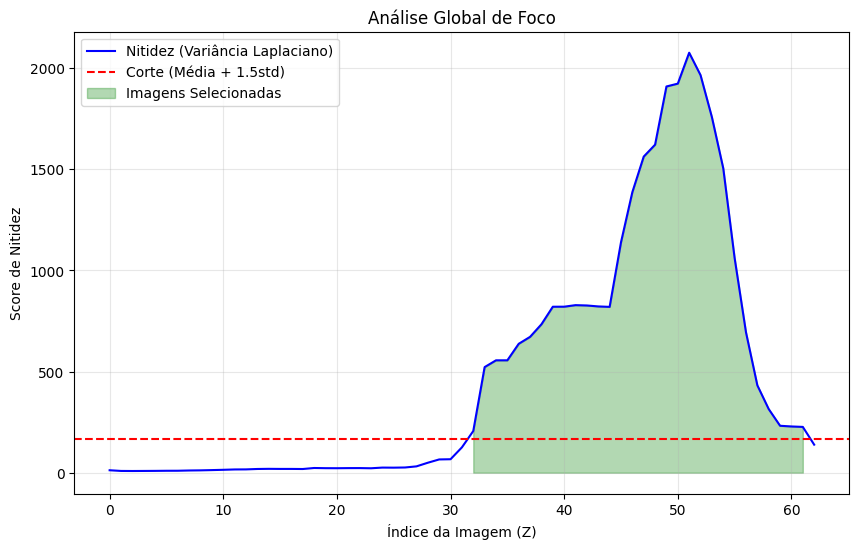

Total de Imagens: 63
Média da Variância: 472.98
Desvio Padrão: 611.96
Imagens Úteis identificadas: 30
Seleção: Mantendo índices 32 até 61 (Total: 30 imagens)


In [98]:
images = load_images_from_folder("../images/aligned")
clean_images = global_focus_analysis(images)


[Algoritmo]
Função de Custo selecionada: RMSE
Total de imagens na pilha: 30
Iniciando iteração no intervalo I = [1.0000, 1.2000]
-------------------------------------------------------
[Processando par 0 -> 1]... Otimização concluída em 1.9117s
Melhor Escala Encontrada: 1.0000 (Erro: 8.09)
-------------------------------------------------------
[Processando par 1 -> 2]... Otimização concluída em 1.9079s
Melhor Escala Encontrada: 1.0008 (Erro: 6.31)
-------------------------------------------------------
[Processando par 2 -> 3]... Otimização concluída em 2.0944s
Melhor Escala Encontrada: 1.0004 (Erro: 5.43)
-------------------------------------------------------
[Processando par 3 -> 4]... Otimização concluída em 1.6743s
Melhor Escala Encontrada: 1.0004 (Erro: 6.57)
-------------------------------------------------------
[Processando par 4 -> 5]... Otimização concluída em 1.5733s
Melhor Escala Encontrada: 1.0008 (Erro: 6.69)
-------------------------------------------------------
[Pro

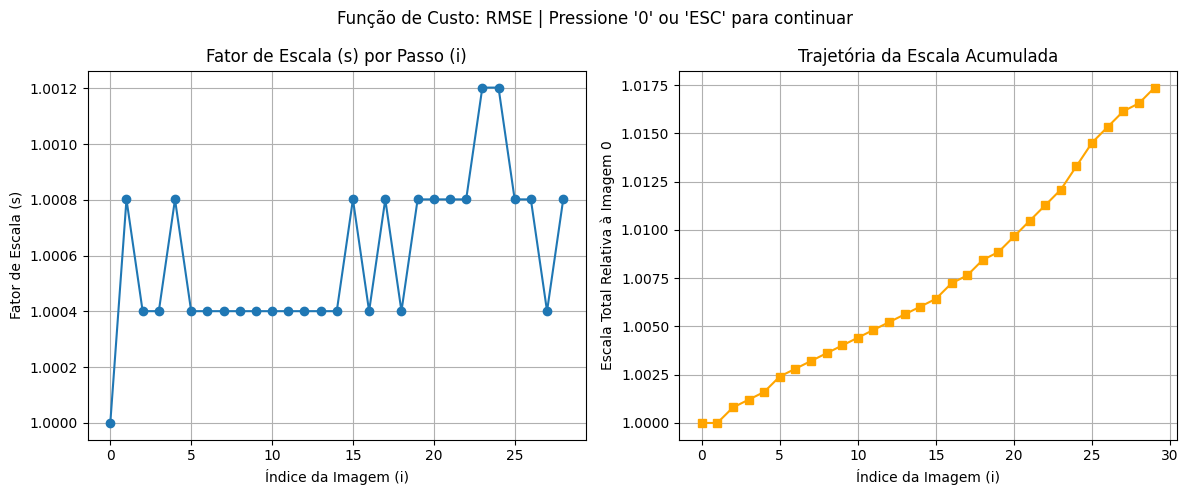

In [99]:
CUSTO = 'RMSE'
MOTOR_STEP_MM = 1.0
INTERVAL = np.linspace(1.00, 1.20, 500)

step_scales, accumulated_scales = algorithm(clean_images, CUSTO, INTERVAL, debug=True)

In [100]:
# DataFrames.
imgs_idx = np.arange(0, len(step_scales), 1)
df = pd.DataFrame(columns=['imagens', 'escalas', 'escalas_acumuladas'])
df['imagens'] = imgs_idx
df['escalas'] = step_scales
df['escalas_acumuladas'] = accumulated_scales

In [101]:
depth_map, index_map = calculate_depth_map(clean_images, df['escalas_acumuladas'], MOTOR_STEP_MM)


Iniciando reconstrução 3D (Depth from Focus)
N°: 30
Volume de Dados: 518x388 pixels com 30 camadas.

Calculando nitidez (Laplaciano) por camada...
Mapa de Profundidade calculado com sucesso.


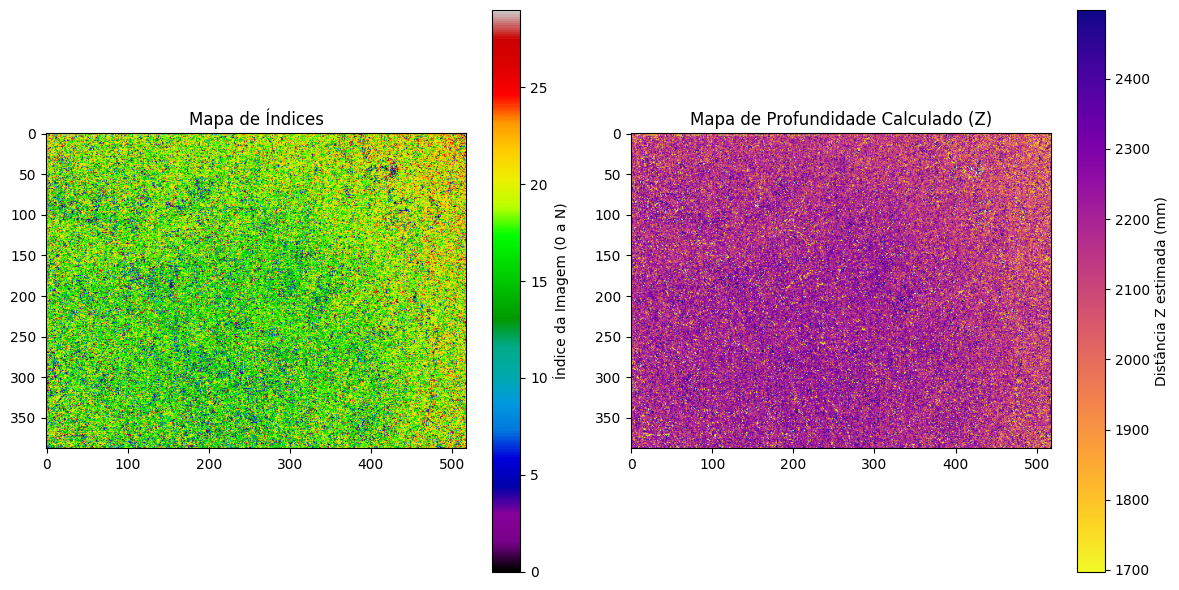

In [102]:
plot_depth(depth_map, index_map)

In [147]:
depth_map_final, depth_map_raw, index_map = calculate_depth_map_refined(clean_images, accumulated_scales, MOTOR_STEP_MM, agg_window=1, d=13, h_thr=200, px_thr=15)

--- INICIANDO ESTIMATIVA DE PROFUNDIDADE ---
FASE 1: Calculando foco com Agregação Espacial (Janela 1x1)...
FASE 2: Aplicando Filtro Bilateral no Mapa de Profundidade...
Reconstrução concluída com sucesso.


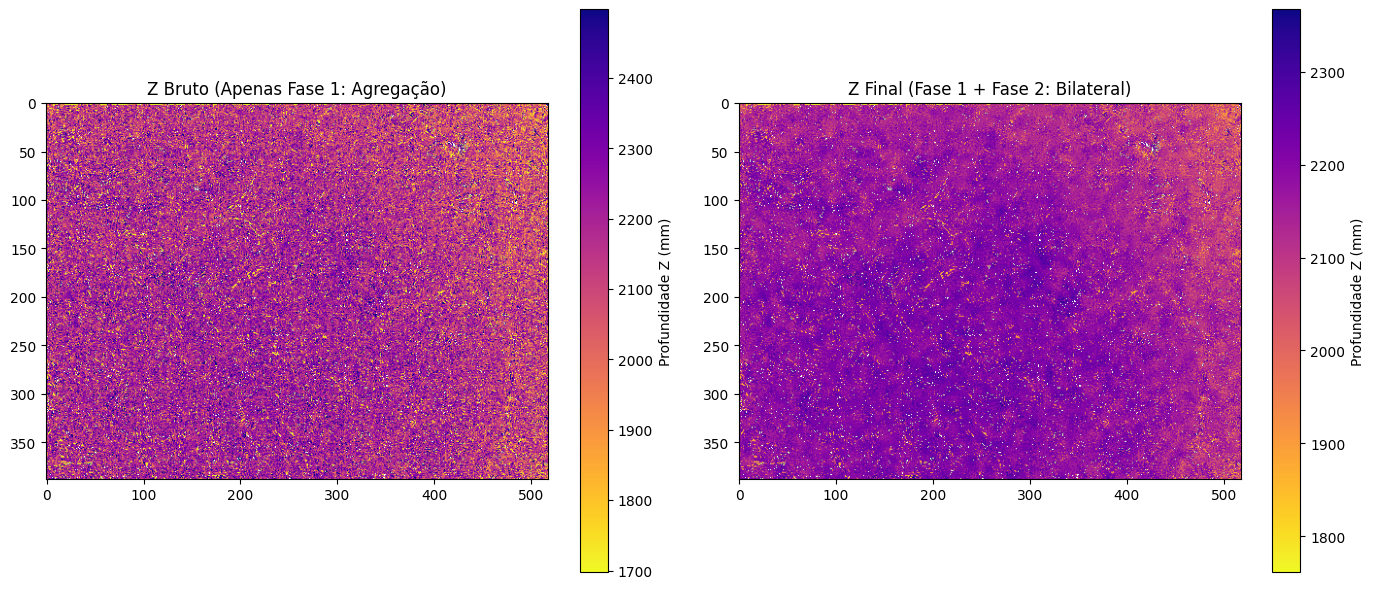

In [148]:
compare_filters(depth_map_raw, depth_map_final)

## Análise do Foco Global das Imagens com Keypoints.
| Este código analisa a distribuição de foco da stack de imagens utilizando os pontos de interesse do AKAZE, e seleciona as camadas dentro do limiar definido, μ - kσ (k = 0.5), que abrange aproximadamente 67% das imagens.

In [ ]:
def analyze_keypoint_density(aligned_images, desvios_padrao=1, show=True):
    """
    Analisa a qualidade do foco contando a densidade de pontos de interesse (Keypoints)
    e aplica um filtro estatístico (Gaussiano) para selecionar as imagens úteis.
    
    Args:
        aligned_images: Lista de imagens.
        desvios_padrao: Fator de corte (Z-score).
        show: Se True, plota o gráfico de distribuição.
        
    Returns:
        imagens_filtradas: Sublista apenas com as imagens focadas.
        indices_uteis: Lista dos índices originais mantidos.
        range_z: Tupla (inicio, fim) para referência.
    """
    print(f"--- ANÁLISE DE DENSIDADE DE KEYPOINTS (Gaussian Cut: {desvios_padrao}σ) ---")
    
    # Inicializa detector (ORB é rápido e robusto a ruído)
    # Ajustamos nfeatures para um valor alto para não saturar
    orb = cv2.ORB_create(nfeatures=10000, scoreType=cv2.ORB_HARRIS_SCORE)
    
    keypoint_counts = []
    
    # 1. Extração de Dados
    for i, img in enumerate(aligned_images):
        if img.ndim == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img
            
        # Detectar keypoints (não precisamos dos descritores, apenas os pontos)
        kps = orb.detect(gray, None)
        count = len(kps)
        keypoint_counts.append(count)

    counts_arr = np.array(keypoint_counts)
    
    # 2. Análise Estatística (Gaussiana)
    media = np.mean(counts_arr)
    std = np.std(counts_arr)
    
    # Definição do Limiar (Threshold)
    # Queremos apenas as imagens que têm MUITO mais detalhes que a média
    limiar_corte = media - (desvios_padrao * std)
    
    print(f"Estatísticas -> Média: {media:.1f} pts | Std: {std:.1f} pts")
    print(f"Critério de Corte: > {limiar_corte:.1f} pontos")
    
    # 3. Filtragem
    indices_uteis = np.where(counts_arr > limiar_corte)[0]
    
    if len(indices_uteis) == 0:
        print("ALERTA: Nenhuma imagem passou no critério. O desvio padrão está muito alto ou as imagens estão sem textura.")
        return [], [], (0,0)
    
    # Para manter a continuidade do volume 3D, pegamos do primeiro ao último índice válido
    idx_start = indices_uteis[0]
    idx_end = indices_uteis[-1]
    
    imagens_filtradas = aligned_images[idx_start : idx_end+1]
    
    print(f"Seleção: Mantendo índices {idx_start} até {idx_end} (Total: {len(imagens_filtradas)} imagens)")

    # 4. Visualização
    if show:
        plt.figure(figsize=(10, 6))
        
        # Plot da curva de densidade
        x = range(len(aligned_images))
        plt.plot(x, counts_arr, label='Qtd. Keypoints', color='navy', linewidth=2)
        plt.fill_between(x, 0, counts_arr, alpha=0.1, color='blue')
        
        # Plot da área selecionada
        plt.axhline(y=media, color='gray', linestyle=':', label='Média')
        plt.axhline(y=limiar_corte, color='red', linestyle='--', label=f'Corte ({desvios_padrao}σ)')
        
        # Destacar a região aprovada
        plt.axvspan(idx_start, idx_end, color='green', alpha=0.2, label='Volume de Foco Útil')
        
        plt.title("Distribuição Gaussiana de Foco")
        plt.xlabel("Índice da Imagem (Profundidade Z)")
        plt.ylabel("Contagem de Pontos de Interesse")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return imagens_filtradas, indices_uteis, (idx_start, idx_end)

--- ANÁLISE DE DENSIDADE DE KEYPOINTS (Gaussian Cut: 0.5σ) ---
Estatísticas -> Média: 4097.2 pts | Std: 3901.3 pts
Critério de Corte: > 2146.6 pontos
Seleção: Mantendo índices 31 até 62 (Total: 32 imagens)


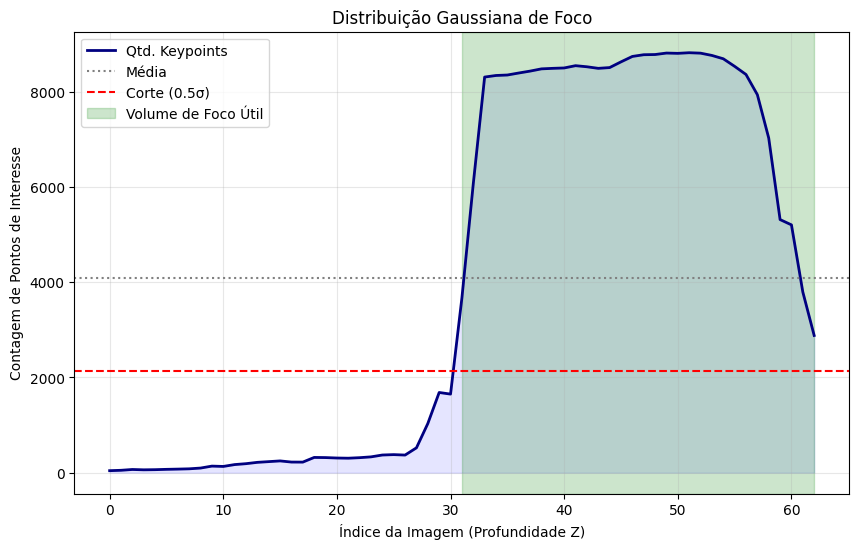

In [ ]:
imgs_clean, indices_reais, range_z = analyze_keypoint_density(images, desvios_padrao=0.5, show=True)